# Week 9: Other Applications of Reinforcement Learning

**FYS4411 — Reinforcement Learning and Agentic AI**  
University of Oslo, Department of Physics

*Physics-informed systems, molecular discovery, robotics, and research frontiers*

This notebook is self-contained and executable. It combines a concise repetition of the lecture, equations, reproducible numerical examples, visual diagnostics, and a short problem set. No API key or external service is required.

In [1]:
import math
import re
from dataclasses import dataclass, field
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(9)
UIO_PURPLE = "#4338B5"
UIO_GREEN = "#2A9D8F"
UIO_RED = "#C84C4C"
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (8.5, 4.8),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "legend.frameon": False,
})

## Learning goals

After completing this notebook, you should be able to

- formulate a scientific problem as an MDP or constrained POMDP;
- distinguish reinforcement learning from prediction, system identification, and static optimization;
- explain how physics-informed models can support control without themselves being RL agents;
- implement compact examples of adaptive PDE sampling, molecular enhanced sampling, and residual robotic control;
- evaluate scientific RL with physical baselines, uncertainty tests, and an evidence ladder;
- identify credible RL research opportunities in medicine, neuroscience, finance, weather, energy, fisheries, and other domains.

## 1. When does a scientific problem become reinforcement learning?

A scientific problem becomes an RL problem only after its **decisions** are explicit. An MDP is

$$
\mathcal M=(\mathcal S,\mathcal A,P,r,\gamma),
$$

with a policy $\pi(a\mid s)$ and objective

$$
J(\pi)=\mathbb E_\pi\!\left[\sum_{t=0}^{T-1}\gamma^t r(S_t,A_t)+\gamma^T r_T(S_T)\right].
$$

In science, the state is often only partially observed. A history $h_t=(o_0,a_0,\ldots,o_t)$, a recurrent state, or a belief distribution $b_t(s)=p(s_t=s\mid h_t)$ may therefore replace the true physical state.

| Scientific component | Example | RL? |
|---|---|---|
| Prediction | forecast a weather field | No: no action or return |
| Static optimization | fit one molecule to a scoring function | Not necessarily |
| System identification | infer a Hamiltonian from measurements | No, unless measurements are selected sequentially |
| Sequential design | choose the next experiment using all previous results | Yes, if optimized as a policy |
| Closed-loop control | change a field after each observation | Yes |

The research advantage is not “using an agent.” It is optimizing **adaptation through time** when actions change later information or physical outcomes.

### Constrained and risk-sensitive objectives

Scientific objectives rarely reduce to expected reward. A constrained formulation is

$$
\max_\pi J_r(\pi)
\quad\text{subject to}\quad
J_{c_k}(\pi)\le d_k,\qquad k=1,\ldots,K,
$$

where costs may represent temperature, toxicity, energy, force, budget, or ethical burden. Rare failures can be expressed through a chance constraint

$$
\Pr_\pi(C_{\mathrm{critical}}>0)\le\delta,
$$

or a tail-risk criterion such as $\operatorname{CVaR}_\alpha$. In a credible scientific study, constraints are reported separately; a large reward must not hide a small number of catastrophic trials.

**Use RL when:** decisions are sequential, feedback matters, delayed outcomes matter, and a safe source of interaction or logged data exists.  
**Prefer another method when:** a differentiable model supports direct optimal control, the task is one-shot, the dataset cannot identify counterfactual actions, or violations cannot be tolerated during learning.

## 2. Physics-informed models and RL

A physics-informed neural network (PINN) approximates a field $u_\theta(x,t)$ while penalizing violations of a governing equation. For

$$
\mathcal N[u](x,t)=f(x,t),
$$

a typical objective is

$$
\mathcal L(\theta)=
\lambda_d\mathcal L_{\mathrm{data}}+
\lambda_f\frac{1}{N_f}\sum_{i=1}^{N_f}
\left\lVert\mathcal N[u_\theta](x_i,t_i)-f(x_i,t_i)\right\rVert^2+
\lambda_b\mathcal L_{\mathrm{boundary}}.
$$

A PINN is a physics-constrained function approximator, **not automatically an RL agent**. The two can meet through four interfaces:

1. a policy selects informative collocation points or experiments;
2. a PINN serves as a differentiable surrogate or world model;
3. PDE residuals shape a reward or safety filter;
4. RL controls boundary conditions, forcing, geometry, or discretization.

The next example isolates the first idea. It uses a fixed random feature map so that the output layer can be fit exactly; the same residual-based acquisition principle also applies to a fully trained PINN.

In [2]:
# Physics-informed random features for u''(x) + pi^2 sin(pi x) = 0,
# u(0)=u(1)=0. The exact solution is u(x)=sin(pi x).
pde_rng = np.random.default_rng(90)
n_features = 28
w_rf = pde_rng.normal(0, 3.0, n_features)
b_rf = pde_rng.uniform(-2.0, 2.0, n_features)

def rf_terms(x):
    x = np.asarray(x)[:, None]
    z = x * w_rf[None, :] + b_rf[None, :]
    phi = np.tanh(z)
    phi_1 = w_rf[None, :] * (1.0 - phi**2)
    phi_2 = -2.0 * w_rf[None, :]**2 * phi * (1.0 - phi**2)
    g, g_1, g_2 = x * (1.0 - x), 1.0 - 2.0 * x, -2.0
    basis = g * phi
    basis_2 = g_2 * phi + 2.0 * g_1 * phi_1 + g * phi_2
    return basis, basis_2

def fit_physics_features(x_col, ridge=2e-7):
    _, A = rf_terms(x_col)
    y = -(np.pi**2) * np.sin(np.pi * np.asarray(x_col))
    return np.linalg.solve(A.T @ A + ridge * np.eye(n_features), A.T @ y)

def pde_predict(coeff, x):
    basis, basis_2 = rf_terms(x)
    u_hat = basis @ coeff
    residual = basis_2 @ coeff + np.pi**2 * np.sin(np.pi * np.asarray(x))
    return u_hat, residual

x_dense = np.linspace(0, 1, 600)
u_exact = np.sin(np.pi * x_dense)

# Uniform design and residual-adaptive design use the same final budget.
budget = 28
x_uniform = np.linspace(0.015, 0.985, budget)
c_uniform = fit_physics_features(x_uniform)

x_adapt = list(np.linspace(0.03, 0.97, 7))
adaptive_rmse, adaptive_residual = [], []
while len(x_adapt) < budget:
    c_now = fit_physics_features(np.array(x_adapt))
    u_now, res_now = pde_predict(c_now, x_dense)
    adaptive_rmse.append(np.sqrt(np.mean((u_now - u_exact)**2)))
    adaptive_residual.append(np.sqrt(np.mean(res_now**2)))
    # Avoid repeatedly selecting almost identical locations.
    distance = np.min(np.abs(x_dense[:, None] - np.array(x_adapt)[None, :]), axis=1)
    score = np.abs(res_now) * np.minimum(1.0, distance / 0.015)
    x_adapt.append(float(x_dense[np.argmax(score)]))

x_adapt = np.sort(np.array(x_adapt))
c_adapt = fit_physics_features(x_adapt)
u_uniform, r_uniform = pde_predict(c_uniform, x_dense)
u_adapt, r_adapt = pde_predict(c_adapt, x_dense)

pde_results = pd.DataFrame({
    "design": ["uniform", "residual-adaptive"],
    "solution RMSE": [np.sqrt(np.mean((u_uniform-u_exact)**2)),
                      np.sqrt(np.mean((u_adapt-u_exact)**2))],
    "residual RMS": [np.sqrt(np.mean(r_uniform**2)),
                     np.sqrt(np.mean(r_adapt**2))],
    "max abs error": [np.max(np.abs(u_uniform-u_exact)),
                      np.max(np.abs(u_adapt-u_exact))],
})
print(pde_results.to_string(index=False, float_format=lambda z: f"{z:.3e}"))

           design  solution RMSE  residual RMS  max abs error
          uniform      1.376e-08     2.164e-05      3.467e-08
residual-adaptive      6.429e-08     1.766e-05      1.251e-07


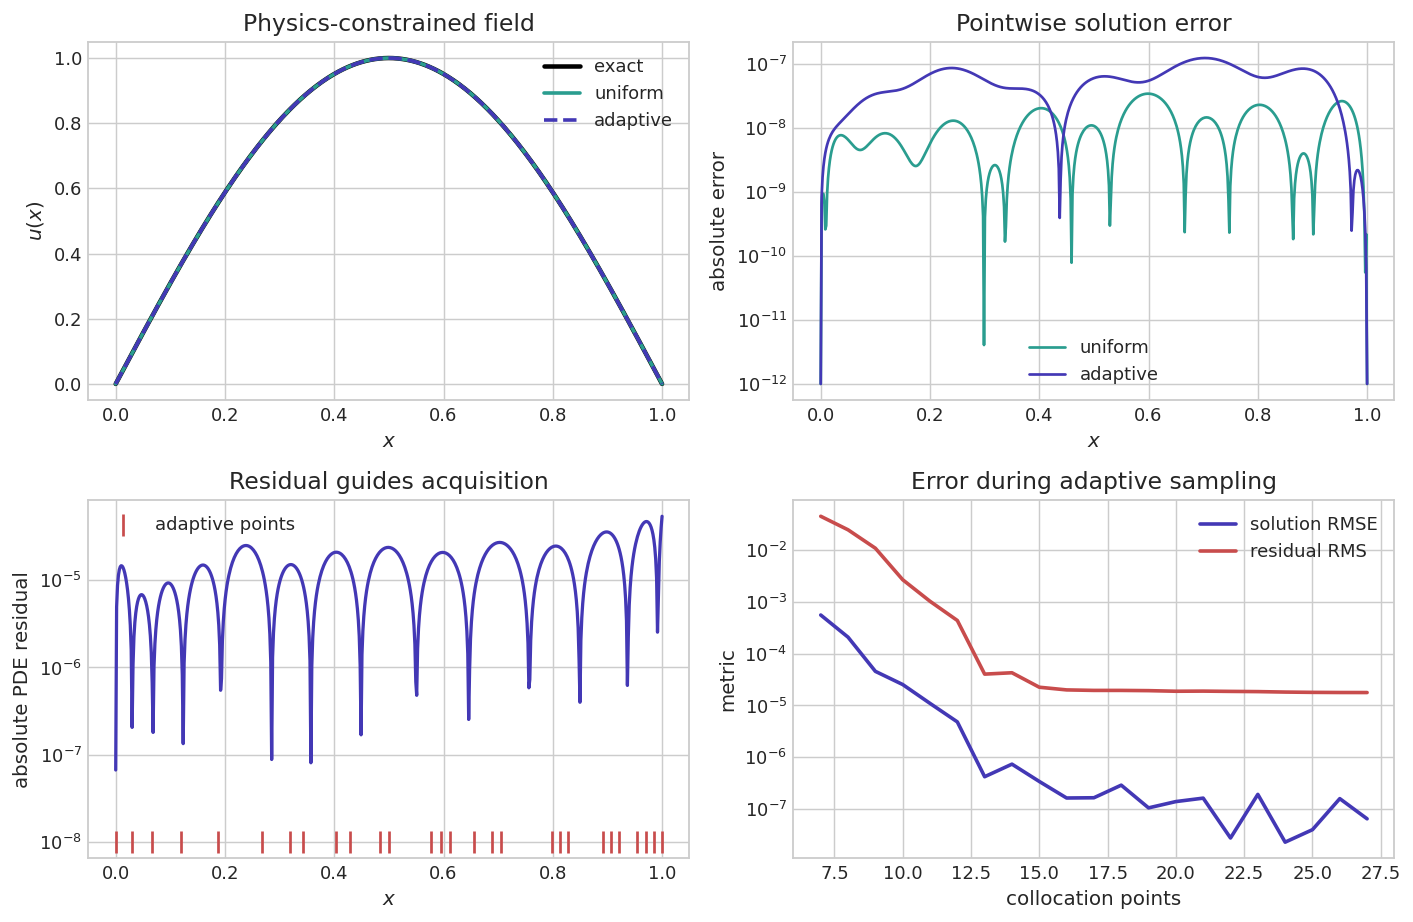

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.2))
axes[0, 0].plot(x_dense, u_exact, color="black", lw=2.5, label="exact")
axes[0, 0].plot(x_dense, u_uniform, color=UIO_GREEN, lw=2, label="uniform")
axes[0, 0].plot(x_dense, u_adapt, color=UIO_PURPLE, lw=2, ls="--", label="adaptive")
axes[0, 0].set(title="Physics-constrained field", xlabel="$x$", ylabel="$u(x)$")
axes[0, 0].legend()

axes[0, 1].semilogy(x_dense, np.abs(u_uniform-u_exact)+1e-12,
                    color=UIO_GREEN, label="uniform")
axes[0, 1].semilogy(x_dense, np.abs(u_adapt-u_exact)+1e-12,
                    color=UIO_PURPLE, label="adaptive")
axes[0, 1].set(title="Pointwise solution error", xlabel="$x$", ylabel="absolute error")
axes[0, 1].legend()

axes[1, 0].semilogy(x_dense, np.abs(r_adapt)+1e-12, color=UIO_PURPLE, lw=1.8)
axes[1, 0].scatter(x_adapt, np.full_like(x_adapt, 1e-8), marker="|", s=150,
                   color=UIO_RED, clip_on=False, label="adaptive points")
axes[1, 0].set(title="Residual guides acquisition", xlabel="$x$", ylabel="absolute PDE residual")
axes[1, 0].legend()

acquisitions = np.arange(7, 7+len(adaptive_rmse))
axes[1, 1].semilogy(acquisitions, adaptive_rmse, color=UIO_PURPLE,
                    lw=2, label="solution RMSE")
axes[1, 1].semilogy(acquisitions, adaptive_residual, color=UIO_RED,
                    lw=2, label="residual RMS")
axes[1, 1].set(title="Error during adaptive sampling", xlabel="collocation points", ylabel="metric")
axes[1, 1].legend()
plt.tight_layout()
plt.show()

### What this demonstration establishes—and what it does not

The residual identifies regions in which the current approximation violates the differential equation. A sequential sampler can allocate a finite evaluation budget there. In a true RL version, the state would summarize the current surrogate and sampled set; an action would choose the next point or region; the reward might be the reduction in validation error per unit cost.

Residual reduction is not sufficient evidence. PINNs can satisfy a sampled residual while giving an inaccurate field, struggle with stiff or multiscale dynamics, and behave poorly outside the collocation distribution. The defensible loop is

$$
\text{train surrogate}\rightarrow\text{propose action}\rightarrow
\text{verify with an independent solver or experiment}\rightarrow\text{update}.
$$

Independent high-resolution residual grids, conservation laws, mesh-refinement studies, and comparison with established numerical solvers are part of the result—not optional post-processing.

## 3. Detailed example: boundary control of a heated rod

Consider the nondimensional heat equation

$$
\partial_t T(x,t)=\kappa\,\partial_{xx}T(x,t),\qquad
T(0,t)=T(1,t)=a_t.
$$

The agent observes a low-dimensional summary of the temperature field and selects a boundary temperature. A finite-difference solver is the **truth environment** in this notebook. A PINN could instead be a learned world model for planning, but final policies should still be verified in the trusted solver.

We use

$$
r_t=-\frac{1}{N}\sum_i(T_i-T^\star)^2-\lambda a_t^2.
$$

This is a small tabular example: its purpose is to make the scientific loop visible, not to claim a state-of-the-art PDE controller.

In [4]:
heat_actions = np.linspace(0.0, 1.0, 5)
n_heat, heat_horizon, diffusion_ratio = 15, 90, 0.22
target_temp = 0.60
mean_edges = np.linspace(0.0, 0.85, 18)
center_edges = np.linspace(0.0, 0.85, 18)

def heat_state(T):
    return (int(np.clip(np.digitize(T.mean(), mean_edges), 0, len(mean_edges))),
            int(np.clip(np.digitize(T[len(T)//2], center_edges), 0, len(center_edges))))

def heat_step(T, boundary):
    new = T.copy()
    new[0] = new[-1] = boundary
    new[1:-1] = T[1:-1] + diffusion_ratio * (T[2:] - 2*T[1:-1] + T[:-2])
    return new

def moving_average(y, width=100):
    y = np.asarray(y, dtype=float)
    return np.convolve(y, np.ones(width)/width, mode="valid")

Q_heat = defaultdict(lambda: np.zeros(len(heat_actions)))
heat_returns = []
heat_rng = np.random.default_rng(91)
for episode in range(4200):
    T = np.full(n_heat, heat_rng.uniform(0.0, 0.12))
    epsilon = max(0.035, 0.85 * (1-episode/4200))
    total = 0.0
    for t in range(heat_horizon):
        s = heat_state(T)
        ai = heat_rng.integers(len(heat_actions)) if heat_rng.random() < epsilon else int(np.argmax(Q_heat[s]))
        a = heat_actions[ai]
        T_new = heat_step(T, a)
        reward = -np.mean((T_new-target_temp)**2) - 0.006*a*a
        if t == heat_horizon-1:
            reward -= 2.0*np.mean((T_new-target_temp)**2)
        target = reward if t == heat_horizon-1 else reward + 0.98*np.max(Q_heat[heat_state(T_new)])
        Q_heat[s][ai] += 0.16 * (target-Q_heat[s][ai])
        T, total = T_new, total+reward
    heat_returns.append(total)

def run_heat(controller, initial=0.05):
    T = np.full(n_heat, initial)
    fields, actions = [T.copy()], []
    for _ in range(heat_horizon):
        if controller == "learned":
            a = heat_actions[int(np.argmax(Q_heat[heat_state(T)]))]
        elif controller == "thermostat":
            a = 1.0 if T.mean() < 0.52 else target_temp
        else:
            a = 0.0
        T = heat_step(T, a)
        fields.append(T.copy()); actions.append(a)
    return np.array(fields), np.array(actions)

heat_runs = {name: run_heat(name) for name in ["off", "thermostat", "learned"]}
heat_summary = []
for name, (fields, actions) in heat_runs.items():
    heat_summary.append({"controller": name,
                         "terminal MSE": np.mean((fields[-1]-target_temp)**2),
                         "mean control": actions.mean(),
                         "control energy": np.mean(actions**2)})
print(pd.DataFrame(heat_summary).to_string(index=False, float_format=lambda z: f"{z:.4f}"))

controller  terminal MSE  mean control  control energy
       off        0.3435        0.0000          0.0000
thermostat        0.0063        0.8222          0.7156
   learned        0.0104        0.7861          0.6493


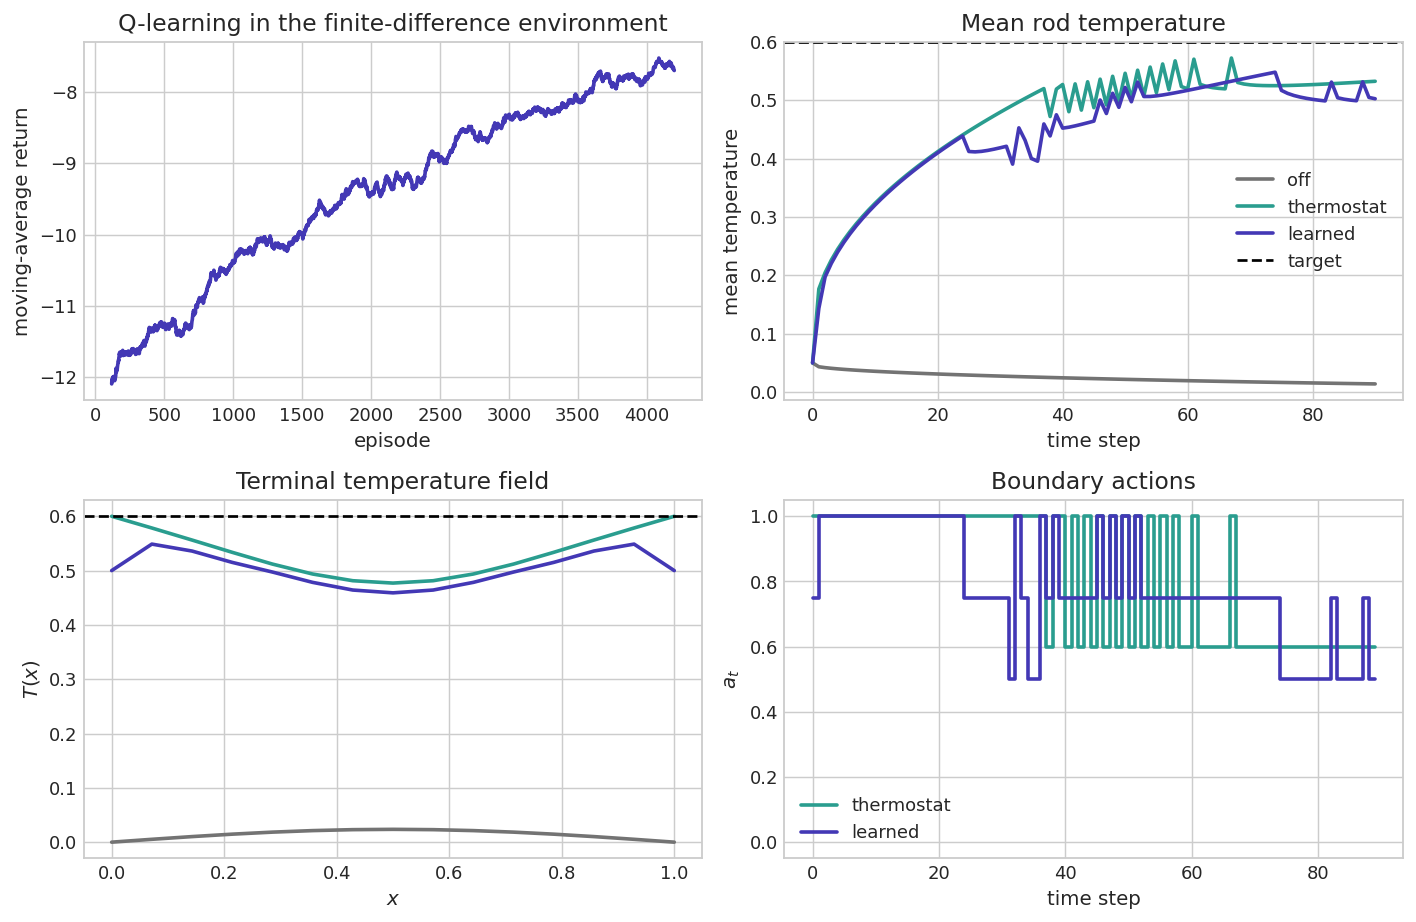

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.2))
ma = moving_average(heat_returns, 120)
axes[0, 0].plot(np.arange(len(ma))+119, ma, color=UIO_PURPLE, lw=2)
axes[0, 0].set(title="Q-learning in the finite-difference environment",
               xlabel="episode", ylabel="moving-average return")

palette = {"off":"0.45", "thermostat":UIO_GREEN, "learned":UIO_PURPLE}
for name, (fields, actions) in heat_runs.items():
    axes[0, 1].plot(fields.mean(axis=1), color=palette[name], lw=2, label=name)
axes[0, 1].axhline(target_temp, color="black", ls="--", label="target")
axes[0, 1].set(title="Mean rod temperature", xlabel="time step", ylabel="mean temperature")
axes[0, 1].legend()

x_rod = np.linspace(0, 1, n_heat)
for name, (fields, actions) in heat_runs.items():
    axes[1, 0].plot(x_rod, fields[-1], color=palette[name], lw=2, label=name)
axes[1, 0].axhline(target_temp, color="black", ls="--")
axes[1, 0].set(title="Terminal temperature field", xlabel="$x$", ylabel="$T(x)$")

axes[1, 1].step(np.arange(heat_horizon), heat_runs["thermostat"][1], where="post",
                color=UIO_GREEN, lw=2, label="thermostat")
axes[1, 1].step(np.arange(heat_horizon), heat_runs["learned"][1], where="post",
                color=UIO_PURPLE, lw=2, label="learned")
axes[1, 1].set(title="Boundary actions", xlabel="time step", ylabel="$a_t$", ylim=(-0.05,1.05))
axes[1, 1].legend()
plt.tight_layout(); plt.show()

### Verification before interpretation

The learned controller should be compared with a simple thermostat, optimal control, and model-predictive control—not only with “no control.” Repeat training over seeds and perturb diffusivity, sensor noise, grid spacing, actuation delay, and initial fields. If a PINN world model is used, test the policy in a solver that was not used to fit that model.

More demanding PDE-control examples include drag reduction around a cylinder, mixing, combustion, and plasma control. These are usually POMDPs: probes reveal only part of a high-dimensional field. The policy should therefore be judged on forces, conservation and stability margins, not only simulator reward.

## 4. Molecular dynamics: use RL to allocate sampling, not to repeal thermodynamics

Molecular applications fall into several distinct categories:

- **generation:** actions edit a graph or sequence;
- **lead optimization:** actions make chemical modifications under multiple objectives;
- **enhanced sampling:** actions choose bias potentials, collective variables, or new starting states;
- **reaction search:** actions expand a pathway or transition tree;
- **closed-loop synthesis:** actions select the next reaction and experiment.

Ordinary molecular dynamics may remain trapped in a metastable basin. In the toy double-well

$$
U(x)=(x^2-1)^2,
$$

we let an agent select a bounded force $b_t$. Overdamped Langevin dynamics give

$$
x_{t+1}=x_t+\Delta t[-U'(x_t)+b_t]+\sqrt{2\tau\Delta t}\,\xi_t.
$$

The task is to reach the right basin while paying for bias. A scientific production study would reconstruct unbiased kinetics or free energies and validate proposed molecules with increasingly expensive physics and experiments.

In [6]:
mol_actions = np.array([-2.4, 0.0, 2.4])
mol_edges = np.linspace(-2.0, 2.0, 51)
mol_horizon, mol_dt, mol_temperature = 140, 0.015, 0.09

def mol_state(x):
    return int(np.clip(np.digitize(x, mol_edges), 0, len(mol_edges)))

def mol_step(x, bias, local_rng):
    grad_u = 4*x*(x*x-1)
    x_new = x + mol_dt*(-grad_u+bias) + np.sqrt(2*mol_temperature*mol_dt)*local_rng.normal()
    return float(np.clip(x_new, -2.0, 2.0))

Q_mol = np.zeros((len(mol_edges)+1, len(mol_actions)))
mol_returns, mol_success = [], []
mol_rng = np.random.default_rng(92)
for episode in range(5000):
    x = float(mol_rng.normal(-1.0, 0.08))
    epsilon = max(0.08, 0.95*(1-episode/5000))
    total, reached = 0.0, False
    for t in range(mol_horizon):
        s = mol_state(x)
        ai = mol_rng.integers(3) if mol_rng.random() < epsilon else int(np.argmax(Q_mol[s]))
        bias = mol_actions[ai]
        x_new = mol_step(x, bias, mol_rng)
        reached = x_new > 0.55
        # Potential-based progress shaping makes the rare crossing learnable
        # without changing the scientific endpoint (arrival in the right basin).
        reward = (-0.004 - 0.0008*bias*bias
                  + 0.50*(x_new-x) + (4.0 if reached else 0.0))
        terminal = reached or t == mol_horizon-1
        target = reward if terminal else reward + 0.99*np.max(Q_mol[mol_state(x_new)])
        Q_mol[s, ai] += 0.13*(target-Q_mol[s, ai])
        x, total = x_new, total+reward
        if terminal: break
    mol_returns.append(total); mol_success.append(reached)

def evaluate_molecular(controller, n_episodes=700, seed=930):
    local_rng = np.random.default_rng(seed)
    records, sample_paths = [], []
    for ep in range(n_episodes):
        x = float(local_rng.normal(-1.0, 0.08)); effort = 0.0; path = [x]
        reached = False
        for t in range(mol_horizon):
            if controller == "learned": bias = mol_actions[np.argmax(Q_mol[mol_state(x)])]
            elif controller == "constant bias": bias = mol_actions[-1]
            else: bias = 0.0
            x = mol_step(x, bias, local_rng); path.append(x); effort += bias*bias
            if x > 0.55:
                reached = True; break
        records.append((reached, t+1, effort/(t+1)))
        if ep < 8: sample_paths.append(path)
    arr = np.asarray(records, dtype=float)
    return arr, sample_paths

molecular_eval = {name: evaluate_molecular(name, seed=930+i)
                  for i, name in enumerate(["unbiased", "constant bias", "learned"])}
mol_table = pd.DataFrame([
    {"policy": name, "success probability": values[0][:,0].mean(),
     "mean steps": values[0][:,1].mean(), "mean squared bias": values[0][:,2].mean()}
    for name, values in molecular_eval.items()
])
print(mol_table.to_string(index=False, float_format=lambda z: f"{z:.3f}"))

       policy  success probability  mean steps  mean squared bias
     unbiased                0.000     140.000              0.000
constant bias                0.994      64.676              5.760
      learned                0.981      73.367              5.126


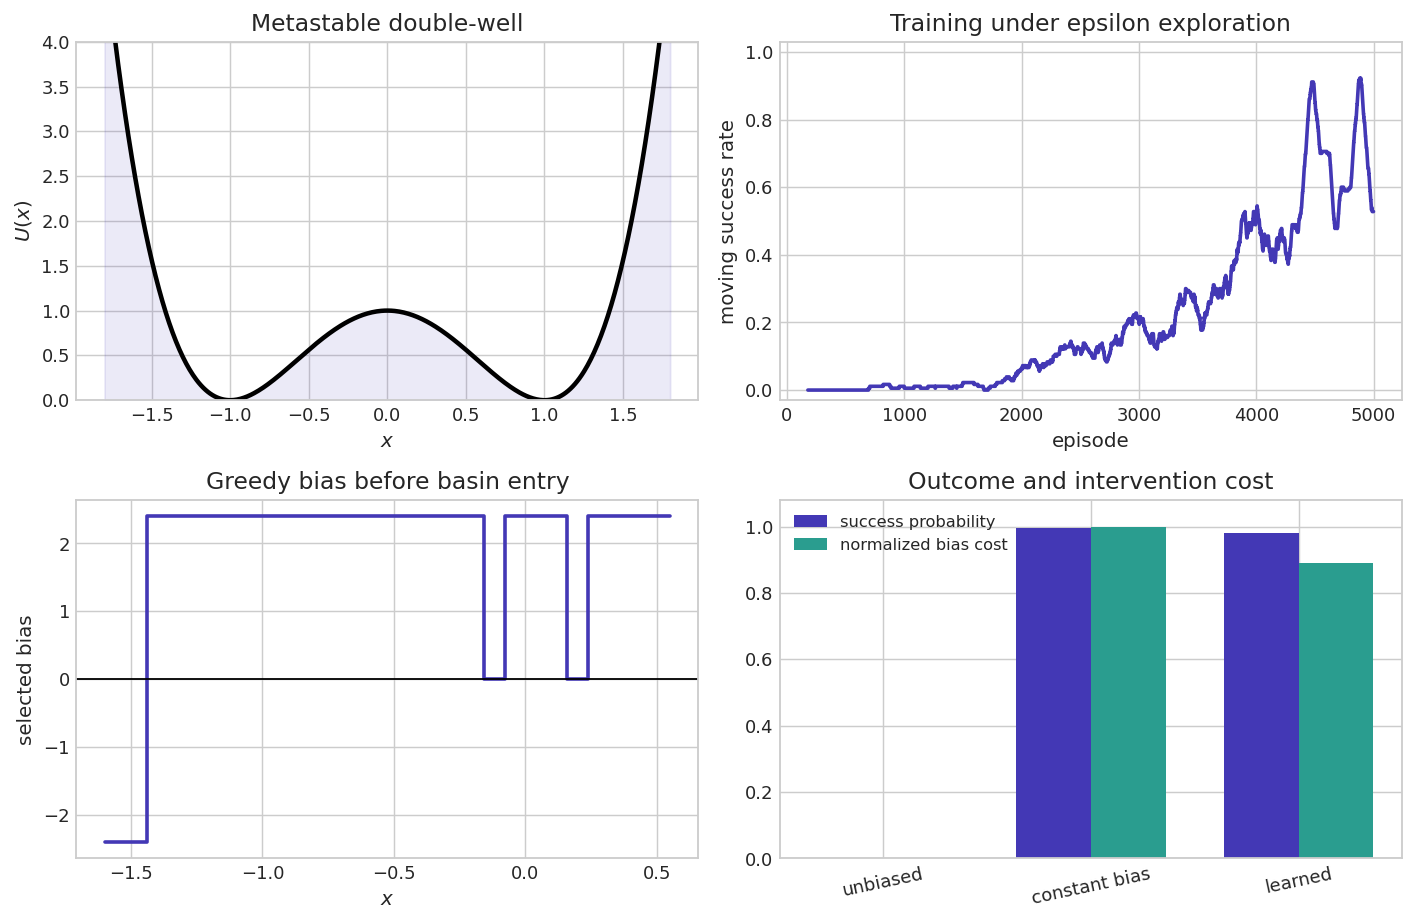

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.2))
x_plot = np.linspace(-1.8, 1.8, 500)
potential = (x_plot*x_plot-1)**2
axes[0, 0].plot(x_plot, potential, color="black", lw=2.5)
axes[0, 0].fill_between(x_plot, 0, potential, color=UIO_PURPLE, alpha=0.10)
axes[0, 0].set(title="Metastable double-well", xlabel="$x$", ylabel="$U(x)$", ylim=(0,4))

success_ma = moving_average(mol_success, 180)
axes[0, 1].plot(np.arange(len(success_ma))+179, success_ma, color=UIO_PURPLE, lw=2)
axes[0, 1].set(title="Training under epsilon exploration", xlabel="episode",
               ylabel="moving success rate", ylim=(-0.03,1.03))

# The episode terminates at x=0.55, so actions beyond it are undefined.
state_centres = np.linspace(-1.6, 0.55, 300)
learned_bias = [mol_actions[np.argmax(Q_mol[mol_state(x)])] for x in state_centres]
axes[1, 0].step(state_centres, learned_bias, where="mid", color=UIO_PURPLE, lw=2)
axes[1, 0].axhline(0, color="black", lw=1)
axes[1, 0].set(title="Greedy bias before basin entry", xlabel="$x$", ylabel="selected bias")

labels = list(molecular_eval)
probs = [molecular_eval[name][0][:,0].mean() for name in labels]
efforts = [molecular_eval[name][0][:,2].mean() for name in labels]
xloc = np.arange(len(labels))
axes[1, 1].bar(xloc-0.18, probs, 0.36, color=UIO_PURPLE, label="success probability")
axes[1, 1].bar(xloc+0.18, np.array(efforts)/(max(efforts)+1e-12), 0.36,
               color=UIO_GREEN, label="normalized bias cost")
axes[1, 1].set_xticks(xloc, labels, rotation=12)
axes[1, 1].set(title="Outcome and intervention cost", ylim=(0,1.08))
axes[1, 1].legend(fontsize=9)
plt.tight_layout(); plt.show()

### Molecular validation ladder

A high reward from a learned surrogate is the beginning of validation, not the endpoint.

1. **Validity and novelty:** valence, sanitization, duplicates, synthetic plausibility.
2. **Independent computation:** docking, conformer ensembles, free-energy calculations, uncertainty.
3. **Mechanistic checks:** selectivity, stability, off-targets, causal interpretation.
4. **Wet-lab assay:** preregistered endpoints and negative controls.
5. **Replication and translation:** independent laboratory, pharmacokinetics, safety.

AlphaFold is an important scientific foundation model, but structure prediction alone is not RL. It becomes one component in a sequential decision system when an agent selects which sequence to mutate, which structure to measure, or which experiment to perform next.

## 5. Robotics and control: residual RL around trusted structure

Classical control remains an essential baseline. If a known controller $u_{\mathrm{base}}(s)$ is useful but imperfect, a residual policy can learn

$$
u_t=\operatorname{clip}\!\left(u_{\mathrm{base}}(s_t)+u_{\mathrm{RL}}(s_t),u_{\min},u_{\max}\right).
$$

This reduces the learning burden and preserves interpretable structure. Safety can be enforced through a control-barrier filter that projects a proposed action onto a set satisfying

$$
\dot h(s,u)+\alpha h(s)\ge 0.
$$

The example below stabilizes an uncertain inverted pendulum. The base PD controller is deliberately under-powered. Tabular Q-learning selects a small residual torque; every executed action is clipped by a hard actuator limit.

In [8]:
residual_actions = np.array([-3.2, 0.0, 3.2])
theta_edges = np.linspace(-1.1, 1.1, 35)
omega_edges = np.linspace(-4.5, 4.5, 35)
robot_horizon, robot_dt = 240, 0.02

def robot_state(theta, omega):
    return (int(np.clip(np.digitize(theta, theta_edges), 0, len(theta_edges))),
            int(np.clip(np.digitize(omega, omega_edges), 0, len(omega_edges))))

def robot_step(theta, omega, residual, torque_bias):
    base = -8.0*theta - 1.8*omega
    torque = float(np.clip(base+residual, -12.0, 12.0))
    acceleration = 9.81*np.sin(theta) + torque - 0.14*omega + torque_bias
    omega_new = omega + robot_dt*acceleration
    theta_new = theta + robot_dt*omega_new
    return theta_new, omega_new, torque, base

Q_robot = defaultdict(lambda: np.zeros(len(residual_actions)))
robot_returns, robot_survival = [], []
robot_rng = np.random.default_rng(94)
for episode in range(5200):
    theta = robot_rng.uniform(-0.42, 0.42); omega = robot_rng.normal(0, 0.12)
    bias = robot_rng.uniform(-0.55, 0.55)
    epsilon = max(0.03, 0.9*(1-episode/5200))
    total, survived = 0.0, True
    for t in range(robot_horizon):
        s = robot_state(theta, omega)
        ai = robot_rng.integers(3) if robot_rng.random() < epsilon else int(np.argmax(Q_robot[s]))
        residual = residual_actions[ai]
        th2, om2, torque, base = robot_step(theta, omega, residual, bias)
        failed = abs(th2) > 1.05 or abs(om2) > 5.0
        reward = 0.02 - th2**2 - 0.04*om2**2 - 0.0012*residual**2 - (4.0 if failed else 0.0)
        terminal = failed or t == robot_horizon-1
        target = reward if terminal else reward + 0.985*np.max(Q_robot[robot_state(th2, om2)])
        Q_robot[s][ai] += 0.13*(target-Q_robot[s][ai])
        theta, omega, total = th2, om2, total+reward
        if terminal:
            survived = not failed; break
    robot_returns.append(total); robot_survival.append(survived)

def evaluate_robot(use_residual, n_trials=500, seed=950):
    local_rng = np.random.default_rng(seed); records=[]; example=None
    for trial in range(n_trials):
        theta=local_rng.uniform(-0.45,0.45); omega=local_rng.normal(0,0.12)
        bias=local_rng.uniform(-0.55,0.55); trace=[]; failed=False
        for t in range(robot_horizon):
            residual = residual_actions[np.argmax(Q_robot[robot_state(theta,omega)])] if use_residual else 0.0
            theta, omega, torque, base = robot_step(theta,omega,residual,bias)
            trace.append((theta,omega,torque,residual))
            if abs(theta)>1.05 or abs(omega)>5.0: failed=True; break
        arr=np.asarray(trace); records.append((not failed, np.sqrt(np.mean(arr[:,0]**2)),
                                                np.mean(np.abs(arr[:,2])), len(arr)))
        if trial==0: example=arr
    return np.asarray(records,dtype=float), example

robot_eval = {"PD only": evaluate_robot(False, seed=950),
              "PD + learned residual": evaluate_robot(True, seed=951)}
robot_table = pd.DataFrame([
    {"controller": name, "survival probability": result[0][:,0].mean(),
     "angle RMS": result[0][:,1].mean(), "mean abs torque": result[0][:,2].mean()}
    for name, result in robot_eval.items()
])
print(robot_table.to_string(index=False, float_format=lambda z:f"{z:.3f}"))

           controller  survival probability  angle RMS  mean abs torque
              PD only                 0.288      0.559            4.387
PD + learned residual                 1.000      0.088            1.912


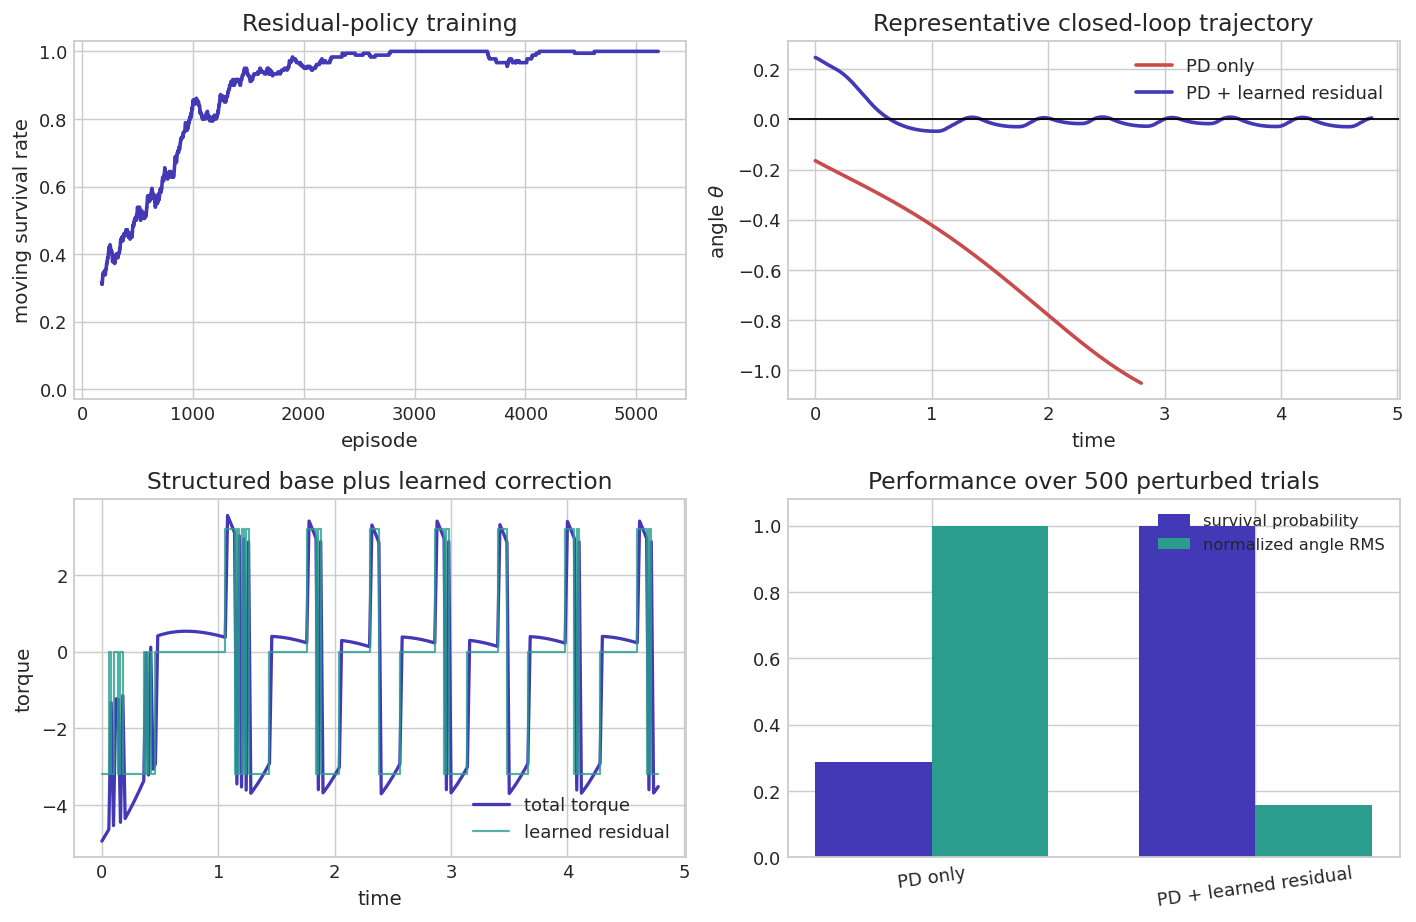

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7.2))
survival_ma = moving_average(robot_survival, 180)
axes[0,0].plot(np.arange(len(survival_ma))+179, survival_ma, color=UIO_PURPLE, lw=2)
axes[0,0].set(title="Residual-policy training", xlabel="episode",
              ylabel="moving survival rate", ylim=(-0.03,1.03))

colors={"PD only":UIO_RED, "PD + learned residual":UIO_PURPLE}
for name, (_, trace) in robot_eval.items():
    axes[0,1].plot(np.arange(len(trace))*robot_dt, trace[:,0], color=colors[name], lw=2, label=name)
axes[0,1].axhline(0,color="black",lw=1)
axes[0,1].set(title="Representative closed-loop trajectory", xlabel="time", ylabel="angle $\\theta$")
axes[0,1].legend()

learned_trace=robot_eval["PD + learned residual"][1]
axes[1,0].plot(np.arange(len(learned_trace))*robot_dt, learned_trace[:,2],
               color=UIO_PURPLE,lw=1.8,label="total torque")
axes[1,0].step(np.arange(len(learned_trace))*robot_dt, learned_trace[:,3],
               color=UIO_GREEN,lw=1.2,alpha=.8,label="learned residual")
axes[1,0].set(title="Structured base plus learned correction", xlabel="time", ylabel="torque")
axes[1,0].legend()

labels=list(robot_eval)
surv=[robot_eval[n][0][:,0].mean() for n in labels]
rms=[robot_eval[n][0][:,1].mean() for n in labels]
xloc=np.arange(2)
axes[1,1].bar(xloc-.18,surv,.36,color=UIO_PURPLE,label="survival probability")
axes[1,1].bar(xloc+.18,np.array(rms)/max(rms),.36,color=UIO_GREEN,label="normalized angle RMS")
axes[1,1].set_xticks(xloc,labels,rotation=8)
axes[1,1].set(title="Performance over 500 perturbed trials",ylim=(0,1.08))
axes[1,1].legend(fontsize=9)
plt.tight_layout(); plt.show()

### From simulation to a physical robot

Randomizing mass, friction, delay, terrain and sensor noise can reduce simulator overfitting, but “domain randomization” is not a proof of transfer. A useful evidence ladder is

$$
\text{nominal simulation}
<\text{perturbed simulation}
<\text{hardware-in-loop}
<\text{restricted hardware}
<\text{operational deployment}.
$$

Examples such as bipedal robot soccer, dexterous manipulation, and tokamak plasma control demonstrate what closed-loop learning can achieve. They also illustrate the engineering around the policy: system identification, action filters, fallback controllers, latency budgets, monitoring, and repeated hardware evaluation.

## 6. Wider scientific applications: identify the decision precisely

| Area | Sequential decision | Plausible reward or objective | Main validation hazard |
|---|---|---|---|
| Medicine | treatment, dose, monitoring time | health outcome minus burden/toxicity | confounding, censoring, distribution shift |
| Neuroscience | stimulus or experiment selection | information gain or therapeutic response | descriptive fit mistaken for mechanism |
| Finance | execution and inventory control | risk-adjusted proceeds minus impact | nonstationarity and backtest leakage |
| Weather | adaptive sensing or data-assimilation control | forecast improvement per observation cost | a predictor mislabeled as a policy |
| Energy | storage, grid, building or reactor control | cost, emissions, stability margins | rare extremes absent from training |
| Aquaculture | feeding and growth trajectory control | growth minus feed, welfare and energy costs | unobserved health and site effects |
| Wild fisheries | adaptive harvest under population uncertainty | long-run yield subject to stock constraints | model error and ecological irreversibility |
| Agriculture | irrigation, fertilizer, pest intervention | yield minus resources and ecosystem cost | weather and soil shift |
| Networks | routing, congestion and scheduling | latency, energy and reliability | endogenous demand response |
| Chip design | sequential placement decisions | timing, power and area | weak baselines and reproducibility |

A weather foundation model can supply forecasts or compact state representations; it is not itself RL. A dynamic treatment regime can be formulated as RL; observational clinical data do not automatically identify the effect of actions that were rarely taken.

In [10]:
# A compact decision audit: the values are illustrative, not empirical scores.
audit = pd.DataFrame({
    "case": ["weather forecasting", "adaptive weather sensing", "protein structure prediction",
             "closed-loop molecule design", "retrospective treatment policy", "robot control"],
    "sequential actions": [False, True, False, True, True, True],
    "actions affect future data": [False, True, False, True, True, True],
    "safe online interaction": [False, True, False, True, False, True],
    "independent validation available": [True, True, True, True, True, True],
})
audit["RL formulation natural?"] = (audit["sequential actions"] &
                                    audit["actions affect future data"])
print(audit.to_string(index=False))

                          case  sequential actions  actions affect future data  safe online interaction  independent validation available  RL formulation natural?
           weather forecasting               False                       False                    False                              True                    False
      adaptive weather sensing                True                        True                     True                              True                     True
  protein structure prediction               False                       False                    False                              True                    False
   closed-loop molecule design                True                        True                     True                              True                     True
retrospective treatment policy                True                        True                    False                              True                     True
                 robot

### Correct and incorrect claims

**Incorrect:** “The weather model is an RL agent because it predicts many future time steps.”  
**Correct:** “A policy uses forecasts to decide where to deploy the next observation platform.”

**Incorrect:** “The treatment policy beats clinicians in logged data.”  
**Correct:** “Under stated causal assumptions, overlap diagnostics, and sensitivity analyses, the estimated policy value exceeds named baselines; prospective evaluation remains necessary.”

**Incorrect:** “The molecular generator discovered a drug.”  
**Correct:** “The policy produced candidates that passed prespecified computational filters; independent physical and experimental validation follows.”

**Incorrect:** “The robot is robust because it survived one randomized simulator.”  
**Correct:** “Across seeds and held-out perturbations, the controller satisfies reported stability and safety metrics; hardware evidence is a separate level.”

## 7. A research workflow that resists self-deception

1. **Specify the decision.** State, action, observation, horizon, constraints, and who bears failures.
2. **Establish identifiability.** Can available data distinguish the consequences of alternative actions?
3. **Build physical baselines.** Heuristics, optimal control, model-predictive control, Bayesian optimization, and supervised models.
4. **Separate environments.** Training simulator, independent verification solver, and held-out physical regimes.
5. **Design the reward from measured endpoints.** Report every important component separately.
6. **Evaluate distributions.** Seeds, uncertainty intervals, worst groups, tail risk, and out-of-distribution conditions.
7. **Escalate evidence gradually.** Offline data $\rightarrow$ simulation $\rightarrow$ laboratory $\rightarrow$ restricted deployment.
8. **Preserve a fallback.** Action shielding, human override, audit logs, and rollback criteria.

Counterfactual policy evaluation deserves particular care. Importance sampling requires adequate action overlap; model-based evaluation inherits model error; fitted value methods inherit function-approximation and coverage assumptions. Agreement between several estimators is useful but does not remove shared confounding.

## 8. What could come next?

- **Digital twins:** continuously updated physical models supporting planning and control.
- **Offline-to-online RL:** conservative learning from historical data followed by tightly bounded interaction.
- **Domain-specific foundation models:** fields, structures, spectra, genomes, and trajectories as state representations or world models.
- **Scientific agents:** policies that allocate simulation, measurement, literature search, and laboratory resources.
- **Multi-objective discovery:** Pareto fronts over performance, cost, safety, sustainability, and uncertainty.
- **Risk-sensitive control:** policies optimized for extremes rather than average laboratory conditions.

The central research opportunity is a validated closed loop:

$$
\text{observe}\rightarrow\text{infer}\rightarrow\text{choose}\rightarrow
\text{act}\rightarrow\text{measure}\rightarrow\text{falsify or update}.
$$

A foundation model can compress prior scientific knowledge. RL can decide what to do next. Neither substitutes for measurement, uncertainty quantification, or a theory of why the intervention should work.

## Problem set

1. Formulate adaptive collocation as an MDP. Which state representation remains invariant to the order of previously sampled points?
2. In the PDE example, replace residual acquisition with uncertainty acquisition from an ensemble of random-feature models. Compare solution error at equal budgets.
3. Derive the finite-difference stability condition for the one-dimensional heat equation. What goes wrong when the diffusion ratio exceeds $1/2$?
4. Add sensor noise and a one-step actuation delay to the heat-control environment. Is the discretized observation still Markov?
5. In the molecular example, vary the bias penalty. Plot the Pareto curve between crossing probability and control effort.
6. Explain why biased transition counts cannot directly estimate unbiased molecular kinetics. Propose a validation strategy.
7. Strengthen the PD controller in the pendulum example. At what point does residual RL cease to offer a meaningful improvement?
8. Write a control-barrier action filter for a scalar safe set $|\theta|\le\theta_{\max}$. State all modeling assumptions.
9. For a treatment policy learned from observational data, describe positivity, consistency, and no-unmeasured-confounding assumptions in domain language.
10. Choose one wider application and write a one-page decision audit: MDP/POMDP, baselines, constraints, evidence level, and falsification test.

**Mini-project.** Select one of the three coded environments. Compare at least two RL algorithms and two non-RL baselines over 20 random seeds. Hold out a physically meaningful parameter shift, report confidence intervals and tail failures, and include one diagnostic that could falsify your preferred interpretation.

## Summary

- RL is useful when an action changes later observations or outcomes; scientific prediction alone is not RL.
- PINNs can provide residuals, representations, and world models, but require independent numerical verification.
- Molecular RL can allocate sampling or design interventions; unbiased physics and experiments remain the arbiter.
- Residual RL combines learned corrections with trusted control structure and hard action limits.
- Medicine, weather, finance, neuroscience, energy, fisheries, and ecology require domain-specific causal and safety arguments.
- Scientific success is an evidence ladder, not a simulator return.

**Further reading from Lecture 9:** Raissi, Perdikaris and Karniadakis, *Physics-informed neural networks*; Popova et al., *Deep reinforcement learning for de novo drug design*; Zhang et al., *Reinforced dynamics for enhanced sampling*; Haarnoja et al., *Learning agile soccer skills for a bipedal robot*; Degrave et al., *Magnetic control of tokamak plasmas through deep reinforcement learning*; and the lecture references on adaptive aquaculture control, fisheries management, energy systems, and chip placement.